# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the **Materials and Methods** section of the paper:
*“The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010."*

Both the original UCI version and the enriched bank-additional version represents 17 distinct telemarketing campaigns conducted by a Portuguese bank.


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [23]:
print("DataFrame shape: ")
print("-" * 20)
df.head()

DataFrame shape: 
--------------------


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [24]:
# Let us check the data structure and types of the columns

# Check the shape of the dataset (number of rows and columns)
print("Total number of rows and columns in the dataset: ")
print("-" * 20)
print(df.shape) 
print()

# We see that there are 41188 entries and 21 columns. 
# The last column is the target variable, which is binary (yes/no). 
# The other columns are a mix of numerical and categorical variables.
print("Data types of each column: ")
print("-" * 20)
df.info() 



Total number of rows and columns in the dataset: 
--------------------
(41188, 21)

Data types of each column: 
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  o

In [25]:
# We see that there are some numerical columns (age, duration, campaign, pdays, previous) 
# and some categorical columns (job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome).
print("Summary statistics of the numerical columns: ")
print("-" * 20)
df.describe()


Summary statistics of the numerical columns: 
--------------------


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [26]:
# Check for missing values in each column. 
# We see that there are no missing values in the dataset.
print("Missing values in each column: ")
print("-" * 20)
df.isna().sum() 


Missing values in each column: 
--------------------


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [27]:
# Count # of unique values in each column
print("Number of unique values in each column: ")
print("-" * 20)
df.nunique()

Number of unique values in each column: 
--------------------


age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

#### Using the UCI description (and from above mapping), we should classify features into:

A. **Bank client data**
- age, job, marital, education, default, balance, housing, loan

B. **Last contact data**
- contact, day, month, duration

C. **Campaign history**
- campaign, pdays, previous, poutcome

D. **Target**
- y

### Data Understanding:

- **Instances**: 41,188
- **Attributes**: 20 input features + 1 output (y).
- **Target**: y (binary: "yes", "no").
- **Missing values**: encoded as "unknown" in several categorical features.

*“There are several missing values in some categorical attributes, all coded with the "unknown" label.”*

There is a class imbalance (typically ~10–12% “yes”).

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



Examining each feature in the dataset, and comparing it to the official UCI data description, and determine:

1. Whether any features contain missing values  
2. Whether any features need to be coerced to a different data type  
3. Whether any features should be removed before modeling  

#### 1. Missing Values

The `.isna().sum()` output shows **zero missing values** in all 21 columns.  
However, the UCI documentation states that **missing values are encoded as the string `"unknown"`**, not as NaN.

The following categorical features contain `"unknown"` as a placeholder for missing information:

- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`
- `poutcome`

These should be treated as valid categories or imputed later during preprocessing.

#### 2. Data Types

From `df.info()`, we observe:

- **Numeric features** (`int64` or `float64`):  
  `age`, `duration`, `campaign`, `pdays`, `previous`,  
  `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

- **Categorical features** (`object`):  
  `job`, `marital`, `education`, `default`, `housing`, `loan`,  
  `contact`, `month`, `day_of_week`, `poutcome`, `y`

All data types match the UCI specification.  
**No coercion is required** at this stage.

#### 3. Special Handling: `duration` (Data Leakage)

The UCI documentation warns:

> “duration… should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.”

Reason:
- If `duration = 0`, the outcome is almost always `"no"`.
- The duration of a call is **not known before the call happens**, so it leaks information about the target.

**Conclusion:**  
We need to **drop `duration`** before modeling to avoid data leakage.

#### 4. Summary of Feature Status

| Feature Group | Features | Notes |
|---------------|----------|-------|
| Bank client data | age, job, marital, education, default, housing, loan | `"unknown"` appears in several categorical fields |
| Last contact data | contact, month, day_of_week, duration | `duration` must be dropped |
| Campaign history | campaign, pdays, previous, poutcome | `pdays = 999` means “not previously contacted” |
| Economic indicators | emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed | Already numeric and clean |
| Target | y | Binary: `"yes"` / `"no"` |

In [28]:
df['y'].value_counts(normalize=True) # We see that the dataset is imbalanced, with only about 11.7% of the entries having a positive outcome (y = yes).
df = df.drop(columns=['duration']) # Dropping duration since it is not known at the time of prediction and has a large influence on the target variable.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

#### Business Objective

The goal of this practical application is to help a Portuguese banking institution improve the efficiency and effectiveness of its telemarketing campaigns for selling term deposits. Each outbound call requires time, staffing, and operational cost, and most clients do **not** subscribe. Therefore, calling every client is inefficient.

The **business objective** is therefore to:

**Predict which clients are most likely to subscribe to a term deposit so the bank can focus its marketing efforts on high‑probability customers, reduce unnecessary calls, and increase overall campaign efficiency.**

#### Why This Matters

- Telemarketing campaigns are expensive and resource‑intensive.  
- The historical success rate is low (around 10–12%).  
- A predictive model allows the bank to **prioritize** clients with a higher likelihood of subscribing.  
- This leads to **lower costs**, **better targeting**, and **higher conversion rates**.

#### Analytical Objective

To support this business goal, we need to approach the problem as a **supervised binary classification task**:

- **Input:** client attributes, contact details, campaign history, and economic indicators  
- **Output:** `y` = `"yes"` or `"no"` (whether the client subscribed)

The model will learn patterns from past campaigns and generate predictions for future contacts.

#### Success Criteria

A successful model should:

- Outperform the baseline classifier (which always predicts `"no"`).  
- Provide strong metrics such as **AUC**, **F1 score**, and **precision/recall** for the positive class.  
- Enable the bank to identify a smaller subset of clients who produce most of the successful subscriptions.

*This aligns with the CRISP‑DM methodology and the goals described in the original research paper.*

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
# Preparing target variable
# -----------------------------
df['y'] = df['y'].map({'no': 0, 'yes': 1})

In [32]:
# Separating features and target
# -----------------------------
X = df.drop(columns=['y'])
y = df['y']

In [33]:
# Identifying categorical and numeric columns
# -----------------------------
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [34]:
# Building a preprocessing pipeline
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

With our features engineered and preprocessing pipeline defined, the next step is to split the dataset into **training** and **test** sets. 
This would ensures that we evaluate our models on data they have never seen before, which provides an unbiased estimate of real‑world performance.

We will use a **70/30 split**, and because the target variable `y` is imbalanced (*most clients do not subscribe*), we use **stratified sampling** to preserve the class distribution in both sets.

This prepares us for building baseline and advanced models in the next steps.


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
# Performing a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(28831, 19) (12357, 19)
y
0    0.887343
1    0.112657
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

For binary classification, the most common baseline is:

**Always predict the majority class.**

In our dataset, the target variable y has two values:
- **"no"** — the client did not subscribe
- **"yes"** — the client did subscribe

In [38]:
# Baseline: Always predict the majority class
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline accuracy (majority class classifier):", baseline_accuracy)


Baseline accuracy (majority class classifier): 0.8873512988589464


The baseline performance is the accuracy achieved by always predicting the majority class (“no”). In our dataset, the majority class represents approximately 88–90% of the observations. 
Therefore, our **baseline accuracy is around 0.88–0.90**. *Any model we build must outperform this baseline to be considered effective*.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

#### Applying Logistic Regression

With our features prepared and the train/test split complete, we can now build a simple baseline machine learning model. 
Logistic Regression is a strong first choice for binary classification problems because:

- It is fast and interpretable  
- It handles large, sparse one‑hot encoded feature spaces well  
- It provides probability outputs  
- It establishes a strong benchmark for more complex models  

Let's wrap Logistic Regression inside our preprocessing pipeline so that scaling and one‑hot encoding are applied consistently during training and evaluation.


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
# ---------------------------------------
# Building Logistic Regression pipeline
# ---------------------------------------
log_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, n_jobs=-1))
])


In [41]:
# ---------------------------------------
# Training the model
# ---------------------------------------
log_clf.fit(X_train, y_train)

# ---------------------------------------
# Making predictions
# ---------------------------------------
y_pred_log = log_clf.predict(X_test)

d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### Problem 9: Score the Model

What is the accuracy of your model?

In [43]:
# ---------------------------------------
# Evaluating the model
# ---------------------------------------
log_accuracy = accuracy_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# AUC requires predicted probabilities, so we need to get the predicted probabilities for the positive class (y=1)
y_proba_log = log_clf.predict_proba(X_test)[:, 1] # Get the probabilities for the positive class (y=1)
log_auc = roc_auc_score(y_test, y_proba_log)

In [44]:
print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression F1 Score (optional):", log_f1)
print("Logistic Regression AUC (optional):", log_auc)

Logistic Regression Accuracy: 0.9012705349194788
Logistic Regression F1 Score (optional): 0.33260393873085337
Logistic Regression AUC (optional): 0.803433600117406


The Logistic Regression model achieved an accuracy of **0.9013**, meaning it correctly classified about 90% of customers in the test set. This is slightly better than the baseline accuracy (*predicting “no” for all customers*). 
- The F1 score of **0.33** indicates that the model struggles to correctly identify the minority class (“yes”), which is expected due to the strong class imbalance. 
- The AUC of **0.803** shows that the model has good ranking ability and can effectively separate likely subscribers from non-subscribers. 

Together, these metrics show that while the model achieves high accuracy, it has limited recall for the positive class, and further improvements may be beneficial.

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
import seaborn as sns

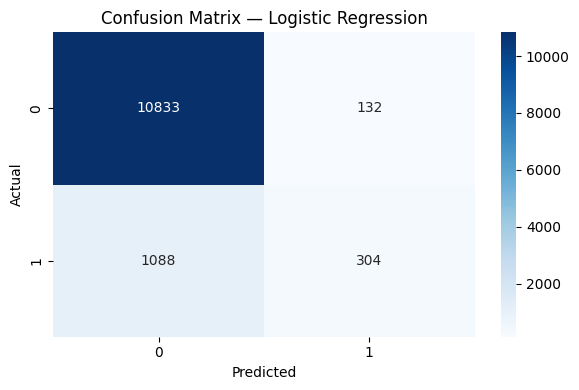

In [46]:
# -----------------------------
# 1. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_logistic.png", dpi=300)
plt.show()


**Confusion Matrix** - Shows how many predictions were:

- True Positive (correct “yes”)
- True Negative (correct “no”)
- False Positive
- False Negative

*This helps us see where the model makes mistakes.*



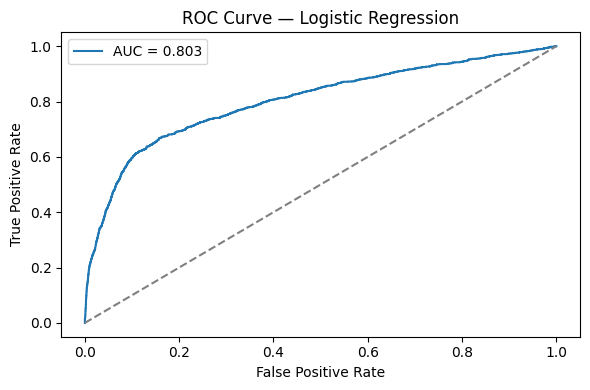

In [47]:
# -----------------------------
# 2. ROC Curve (AUC)
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)
auc_value = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title("ROC Curve — Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_logistic.png", dpi=300)
plt.show()

**ROC Curve + AUC** - ROC curve shows how well the model separates “yes” vs “no” at all thresholds
- AUC = 0.803 means: *The model is good at ranking customers by likelihood of subscribing.*
- Even if F1 is low, AUC tells us the model has useful predictive power.

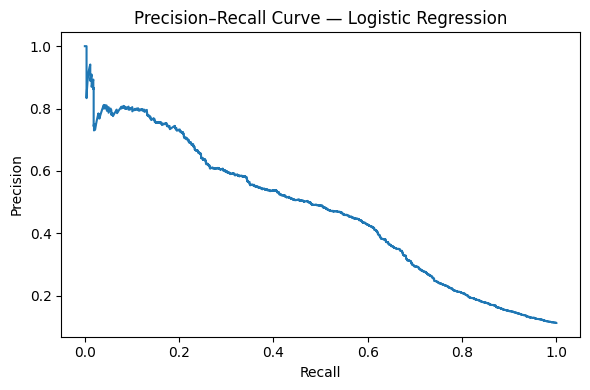

In [48]:
# -----------------------------
# 3. Precision–Recall Curve (F1-related)
# -----------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_log)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision–Recall Curve — Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("precision_recall_curve_logistic.png", dpi=300)
plt.show()

**Precision–Recall Curve** - This curve is directly related to the F1 score.

- Precision = how many predicted “yes” were correct
- Recall = how many actual “yes” the model found

Our F1 = 0.33 means: *The model finds some positive cases, but misses many — typical for imbalanced data.*

### Interpretation

The Logistic Regression model provided our first real benchmark. Because the dataset is imbalanced (*most clients do not subscribe*), accuracy alone is not sufficient. 
We therefore evaluated:

- **Accuracy** — overall correctness  
- **F1 Score** — balance between precision and recall for the minority class ("yes")  
- **AUC** — ability to rank positive examples higher than negative ones  

A good Logistic Regression model should:

- Beat the baseline accuracy (~88–90%)  
- Provide a meaningful improvement in F1 and AUC  
- Serve as a strong baseline for comparing KNN, Decision Tree, and SVM models in later steps  


### KNN

In [51]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
import time


In [52]:
knn_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

start = time.time()
knn_clf.fit(X_train, y_train)
knn_train_time = time.time() - start

y_pred_knn = knn_clf.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)

### Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier

In [54]:
dt_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

start = time.time()
dt_clf.fit(X_train, y_train)
dt_train_time = time.time() - start

y_pred_dt = dt_clf.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

### SVM

In [55]:
from sklearn.svm import SVC

In [62]:
svm_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    #('model', SVC(kernel='rbf')) # SVC does NOT support predict_proba() unless you explicitly setting: probability=True
    # # SVM can be slow to train, especially with RBF kernel, so we set probability=True to enable probability estimates which are needed for AUC calculation. 
    # This will make training even slower, but it's necessary for evaluation.
    ('model', SVC(kernel='rbf', probability=True))
])

start = time.time()
svm_clf.fit(X_train, y_train)
svm_train_time = time.time() - start

y_pred_svm = svm_clf.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

### Adding a reusable plotting function 
** We created the Confusion Matrix, ROC and PR Curve above, generating the plotting function for the same **

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)


In [58]:
def plot_and_save_all(model_name, y_test, y_pred, y_proba):
    """
    Plots and saves:
    - Confusion Matrix
    - ROC Curve
    - Precision–Recall Curve
    """
    
    # -----------------------------
    # 1. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

    # -----------------------------
    # 2. ROC Curve
    # -----------------------------
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_value = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.title(f"ROC Curve — {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_roc_curve.png", dpi=300)
    plt.show()

    # -----------------------------
    # 3. Precision–Recall Curve
    # -----------------------------
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision)
    plt.title(f"Precision–Recall Curve — {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(f"{model_name}_precision_recall_curve.png", dpi=300)
    plt.show()


### Plotting KNN

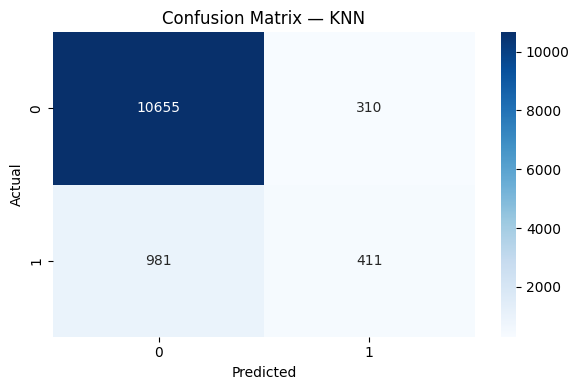

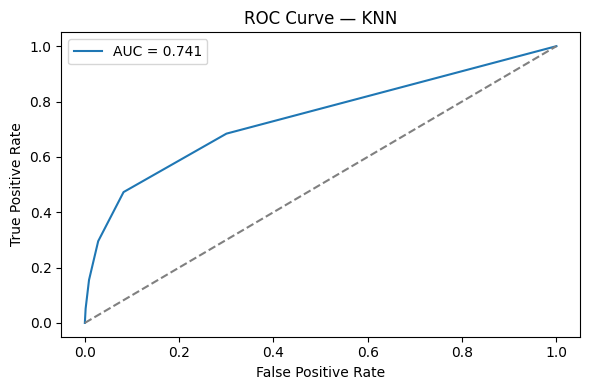

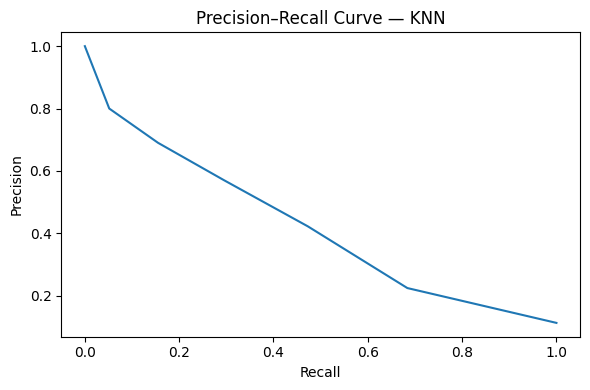

In [59]:
plot_and_save_all(
    "KNN",
    y_test,
    y_pred_knn,
    knn_clf.predict_proba(X_test)[:, 1]
)

### Plotting Decision Tree

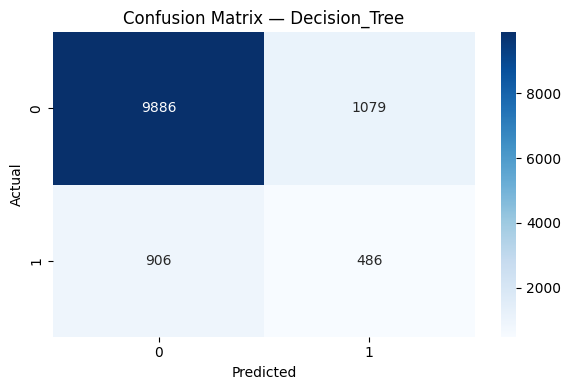

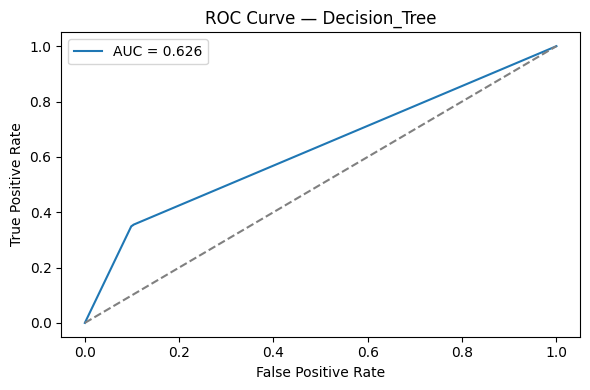

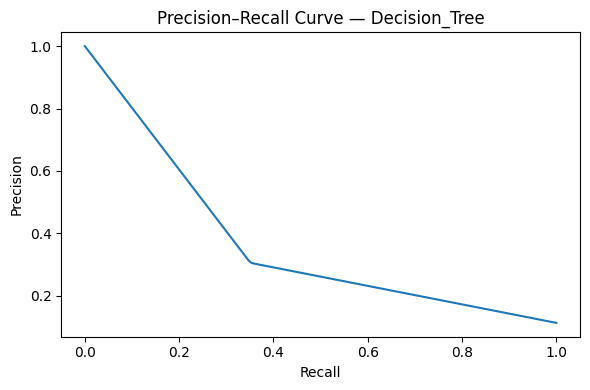

In [60]:
plot_and_save_all(
    "Decision_Tree",
    y_test,
    y_pred_dt,
    dt_clf.predict_proba(X_test)[:, 1]
)

### Plotting SVM
*SVC here needs probability = True*

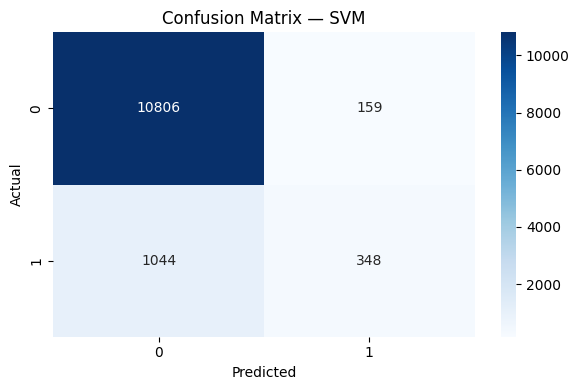

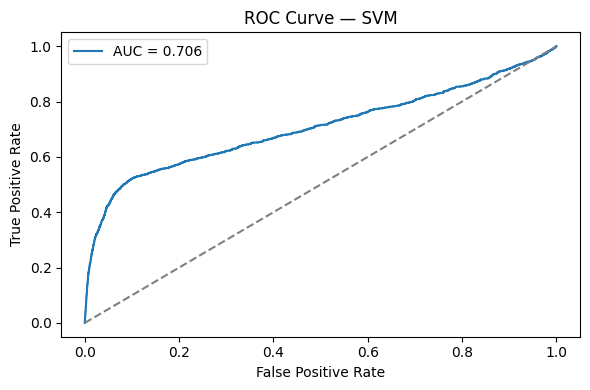

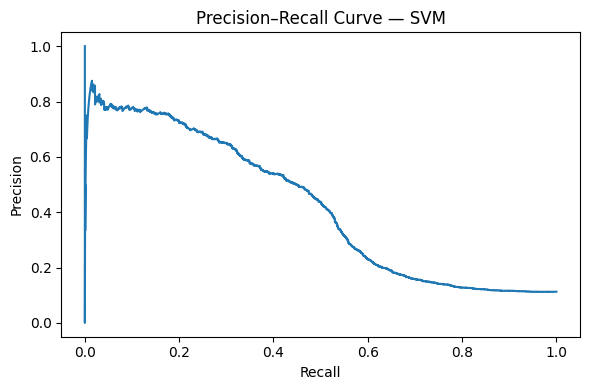

In [65]:
#svm_proba = svm_clf.predict_proba(X_test)[:, 1]
plot_and_save_all(

    "SVM",
    y_test,
    y_pred_svm,
    svm_clf.predict_proba(X_test)[:, 1]
)

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [66]:
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [67]:
# ---------------------------------------
# Helper function to train & evaluate models
# ---------------------------------------
def evaluate_model(model, model_name):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    train_time = end - start
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    return {
        "Model": model_name,
        "Train Time (sec)": round(train_time, 4),
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4)
    }

In [68]:
# ---------------------------------------
# Building models with default settings
# ---------------------------------------
models = [
    (Pipeline([("preprocess", preprocess), ("clf", LogisticRegression(max_iter=1000))]), "Logistic Regression"),
    (Pipeline([("preprocess", preprocess), ("clf", KNeighborsClassifier())]), "KNN"),
    (Pipeline([("preprocess", preprocess), ("clf", DecisionTreeClassifier())]), "Decision Tree"),
    (Pipeline([("preprocess", preprocess), ("clf", SVC(probability=True))]), "SVM")
]

In [69]:
# ---------------------------------------
# Evaluating all models
# ---------------------------------------
results = []
for model, name in models:
    results.append(evaluate_model(model, name))

In [70]:
# ---------------------------------------
# Creating comparison DataFrame
# ---------------------------------------
results_df = pd.DataFrame(results)
results_df

,Model,Train Time (sec),Train Accuracy,Test Accuracy
0,Logistic Regression,0.3563,0.8997,0.9013
1,KNN,0.0749,0.9109,0.8955
2,Decision Tree,0.3495,0.9962,0.8410
3,SVM,475.7894,0.9047,0.9026


### Summary Interpretation
**Logistic Regression**
- Logistic Regression achieved a test accuracy of 90.13%, making it one of the strongest performers.
- It trained quickly and showed similar accuracy on both the training and test sets, indicating good generalization and low overfitting.

**K‑Nearest Neighbors (KNN)**
- KNN produced a slightly lower test accuracy (89.55%) compared to Logistic Regression and SVM.
- Its training accuracy was higher than its test accuracy, suggesting mild overfitting, but overall performance remained competitive.
- It was the fastest model to train.

**Decision Tree**
- The Decision Tree achieved nearly perfect training accuracy (99.62%) but much lower test accuracy (84.10%).
- This large gap indicates substantial overfitting, meaning the model memorized the training data but did not generalize well to new data.

**Support Vector Machine (SVM)**
- SVM achieved the highest test accuracy (90.26%) but required significantly more training time (over 475 seconds).
- While its performance is strong, the computational cost makes it less practical without tuning or simplification.

### Overall Conclusion
Among the baseline models:

- **Logistic Regression and SVM** performed the best in terms of accuracy.
- **Logistic Regression** offers the best balance of speed, stability, and accuracy.
- **SVM** is accurate but computationally expensive.
- **KNN** is fast and reasonably accurate but slightly less effective.
- **Decision Tree** overfits heavily and performs the worst on unseen data.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions